# Shelf Placement Predictor — The 12 Step Method

**Question:** If we place this item here, will it sell fast?  (Answer: Fast, Slow or Ignored)

**Dataset:** `shelf_placement.csv` — keep this file in the **same folder** as this notebook.

**Model we will use:** Logistic Regression

---

### The 12 Steps

| Step | What we do |
|---|---|
| 0 | Install libraries (only once on a new computer) |
| 1 | Import libraries |
| 2 | Import data |
| 3 | Copy data into a DataFrame |
| 4 | Find nulls, outliers, skew and bias |
| 5 | Scaling the data |
| 6 | Fit and transform |
| 7 | Divide into train and test |
| 8 | Train the model (`model.fit`) |
| 9 | Make predictions (`model.predict`) |
| 10 | Check the model on test data |
| 11 | Test with our own new values |
| 12 | Export the model for the web app |

**Every project follows these same 12 steps.** Only the data and the model change.

Run each cell with **Shift + Enter**.

---
# STEP 0 — Install Libraries

Run this cell **only once** on a new computer. After that you can skip it.

If a library is already installed, Python will simply say *"Requirement already satisfied"* —
that is not an error.

In [1]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install joblib

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


**Notes**

- The `!` at the start tells Jupyter to run the command outside Python.
- The library is called **scikit-learn** when installing, but **sklearn** when importing.
- If you are using Anaconda, most of these are already installed.
- After installing, restart the kernel once: menu **Kernel → Restart**.

---
# STEP 1 — Import Libraries

These are the tools we need. We import them once at the top.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Step 1 done - all libraries imported")

Step 1 done - all libraries imported


---
# STEP 2 — Import Data

We read the CSV file directly from the disk.

The file `shelf_placement.csv` must be in the **same folder** as this notebook.

In [3]:
data = pd.read_csv("shelf_placement.csv")

print("Step 2 done - data imported")
print("Rows and Columns:", data.shape)

Step 2 done - data imported
Rows and Columns: (3000, 9)


If your file is somewhere else, write the full path instead:

```python
data = pd.read_csv("C:/AI_Training/shelf_placement.csv")        # Windows
data = pd.read_csv("/home/user/AI_Training/shelf_placement.csv")  # Mac / Linux
```

In Windows always use forward slashes `/` in the path.

---
# STEP 3 — Copy Data into a DataFrame

We make a copy and work on the copy.

The original `data` stays safe, so if we make a mistake we can start again without reading
the file.

In [4]:
df = data.copy()

df.head()

,zone_code,height_code,item_category_code,price,discount_percent,daily_customer_traffic,nearby_promotion,city_code,movement
0,3,2,8,766.0,30.0,260.0,1,1,Slow
1,4,1,6,1145.0,15.0,251.0,1,1,Fast
2,5,1,7,682.0,30.0,140.0,0,2,Slow
3,5,1,2,1354.0,25.0,100.0,0,1,Ignored
4,2,2,3,561.0,5.0,255.0,0,1,Slow


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   zone_code               3000 non-null   int64  
 1   height_code             3000 non-null   int64  
 2   item_category_code      3000 non-null   int64  
 3   price                   2974 non-null   float64
 4   discount_percent        2986 non-null   float64
 5   daily_customer_traffic  2980 non-null   float64
 6   nearby_promotion        3000 non-null   int64  
 7   city_code               3000 non-null   int64  
 8   movement                3000 non-null   str    
dtypes: float64(3), int64(5), str(1)
memory usage: 225.9 KB


In [6]:
df.describe().round(2)

,zone_code,height_code,item_category_code,price,discount_percent,daily_customer_traffic,nearby_promotion,city_code
count,3000.00,3000.00,3000.00,2974.00,2986.00,2980.00,3000.00,3000.00
mean,3.47,1.99,4.49,4819.89,14.95,263.46,0.39,1.39
std,1.69,0.83,2.27,163990.61,9.97,917.18,0.49,0.49
min,1.00,1.00,1.00,111.00,0.00,20.00,0.00,1.00
25%,2.00,1.00,2.75,790.25,5.00,145.00,0.00,1.00
50%,3.00,2.00,5.00,1275.50,15.00,280.00,0.00,1.00
75%,5.00,3.00,6.00,1975.00,25.00,333.00,1.00,2.00
max,6.00,3.00,8.00,8888888.00,30.00,50000.00,1.00,2.00


**Columns**

| Column | Meaning |
|---|---|
| zone_code | where in the shop: 1 Entrance, 2 Near Billing Counter, 3 Front Aisle, 4 Middle Aisle, 5 Back Aisle, 6 Corner Shelf |
| height_code | how high on the rack: 1 Eye Level, 2 Floor Level, 3 Top Shelf |
| item_category_code | 1 Clothing, 2 Electronics, 3 Sweets & Mithai, 4 Home Decor, 5 Footwear, 6 Groceries, 7 Jewellery, 8 Toys |
| price | price of the item in NPR |
| discount_percent | discount on the item (%) |
| daily_customer_traffic | how many customers pass that spot every day |
| nearby_promotion | 1 if there is a promotion banner nearby, else 0 |
| city_code | 1 Kathmandu, 2 Pokhara |
| movement | **Fast / Slow / Ignored — this is our answer (target)** |

---
# STEP 4 — Find Nulls, Outliers, Skew and Bias

## 4.1 Nulls (missing values)

In [7]:
df.isnull().sum()

zone_code                  0
height_code                0
item_category_code         0
price                     26
discount_percent          14
daily_customer_traffic    20
nearby_promotion           0
city_code                  0
movement                   0
dtype: int64

We fill the missing values with the **median** of that column.

We use median (the middle value) because it is not affected by very large wrong values.

In [8]:
df["zone_code"] = df["zone_code"].fillna(df["zone_code"].median())
df["height_code"] = df["height_code"].fillna(df["height_code"].median())
df["item_category_code"] = df["item_category_code"].fillna(df["item_category_code"].median())
df["price"] = df["price"].fillna(df["price"].median())
df["discount_percent"] = df["discount_percent"].fillna(df["discount_percent"].median())
df["daily_customer_traffic"] = df["daily_customer_traffic"].fillna(df["daily_customer_traffic"].median())
df["nearby_promotion"] = df["nearby_promotion"].fillna(df["nearby_promotion"].median())
df["city_code"] = df["city_code"].fillna(df["city_code"].median())

print("Nulls now:", df.isnull().sum().sum())

Nulls now: 0


## 4.2 Outliers

An outlier is a value that is far away from all the others — for example a humidity of 999%
or an age of 200 years.

A **boxplot** shows them. Every dot outside the box is an outlier.

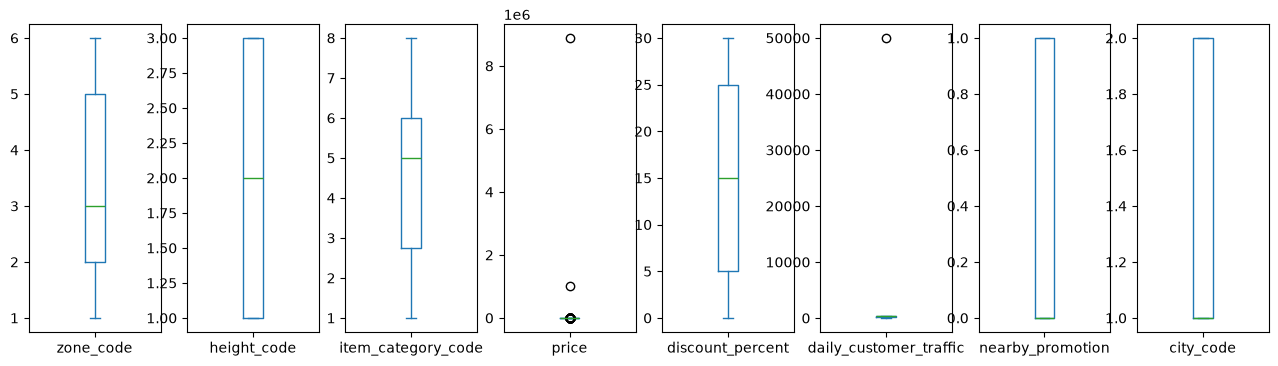

In [9]:
df.plot(kind="box", subplots=True, layout=(1, 8), figsize=(16, 4))
plt.show()

Now we remove the impossible values.

We know the correct range for each column, so we simply keep only the sensible rows.

In [10]:
print("Rows before:", df.shape[0])

df = df[df["price"] <= 100000]
df = df[df["daily_customer_traffic"] <= 2000]
df = df[df["discount_percent"] <= 100]

print("Rows after :", df.shape[0])

Rows before: 3000
Rows after : 2997


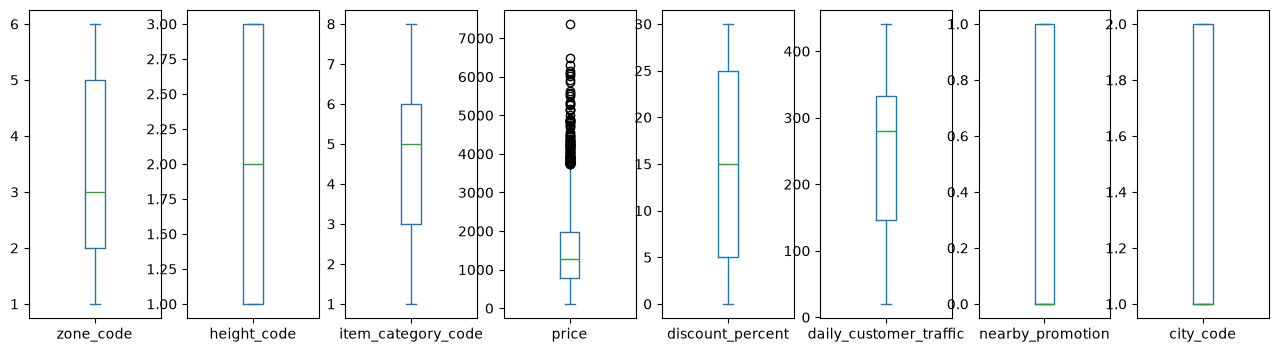

In [11]:
df.plot(kind="box", subplots=True, layout=(1, 8), figsize=(16, 4))
plt.show()

## 4.3 Skew

Skew tells us if the data is balanced or leaning to one side.

| Skew value | Meaning |
|---|---|
| between -0.5 and +0.5 | good, balanced |
| between ±0.5 and ±1 | slightly leaning |
| more than +1 or less than -1 | strongly leaning, should be fixed |

In [12]:
df.skew(numeric_only=True).round(2)

zone_code                 0.03
height_code               0.02
item_category_code       -0.02
price                     1.41
discount_percent         -0.00
daily_customer_traffic   -0.42
nearby_promotion          0.46
city_code                 0.43
dtype: float64

### Now the shape of our own columns

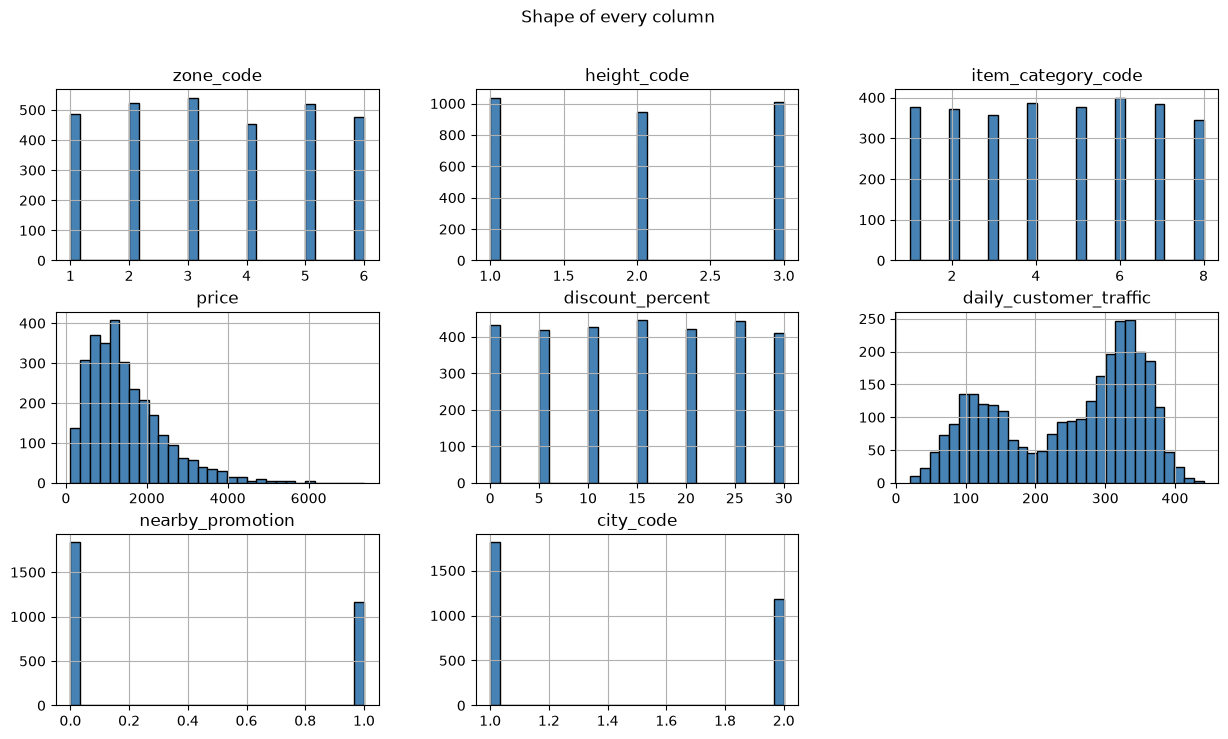

In [14]:
df.hist(figsize=(15, 8), bins=30, color="steelblue", edgecolor="black")
plt.suptitle("Shape of every column")
plt.show()

### How do we FIX skewed data?

If a column is strongly skewed, we squeeze the long tail using a maths function.
The three common fixes are:

| Fix | Code | Use when |
|---|---|---|
| Log transform | `np.log(df["col"] + 1)` | strong positive skew (money, income, sales) |
| Square root | `np.sqrt(df["col"])` | mild positive skew (counts) |
| Square | `df["col"] ** 2` | negative skew |

We add `+ 1` inside the log because `log(0)` does not exist.

**Log is the most used one.** It pulls very large values closer to the rest, without
changing their order.

Our column **`price`** is strongly skewed, so we fix it now with a log transform.

In [16]:
print("Skew BEFORE fix:", round(df["price"].skew(), 2))

df["price"] = np.log(df["price"] + 1)

print("Skew AFTER fix :", round(df["price"].skew(), 2))

Skew BEFORE fix: 1.41
Skew AFTER fix : -0.37


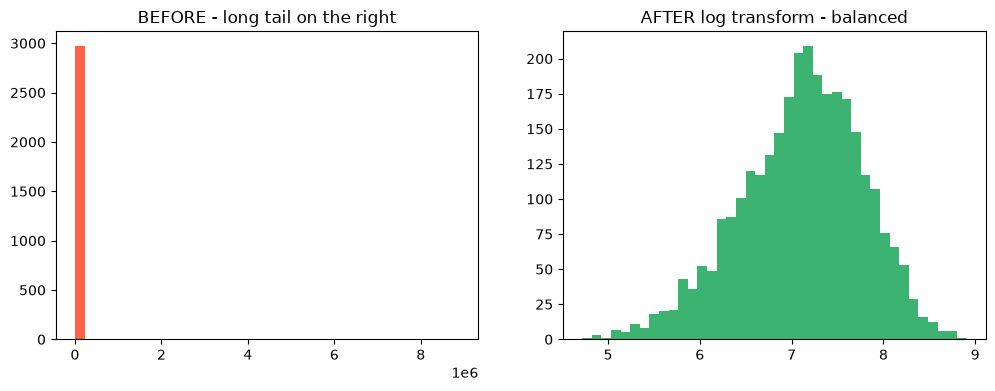

In [17]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(data["price"].dropna(), bins=40, color="tomato")
plt.title("BEFORE - long tail on the right")

plt.subplot(1, 2, 2)
plt.hist(df["price"], bins=40, color="mediumseagreen")
plt.title("AFTER log transform - balanced")

plt.show()

The shape is now balanced.

**Remember this:** because we changed `price` here, the web app must do exactly the same
thing to any new value before predicting. We will handle that in Step 11.

## 4.4 Bias in the data

A dataset is **biased** (also called *imbalanced*) when one answer appears far more often
than the other.

This is dangerous. If 95% of rows say No, a lazy model can answer No every single time and
still be 95% "accurate" — while being completely useless.

Let us check our answer column.

In [18]:
print(df["movement"].value_counts())
print()
print((df["movement"].value_counts(normalize=True) * 100).round(1))

movement
Slow       1050
Ignored    1049
Fast        898
Name: count, dtype: int64

movement
Slow       35.0
Ignored    35.0
Fast       30.0
Name: proportion, dtype: float64


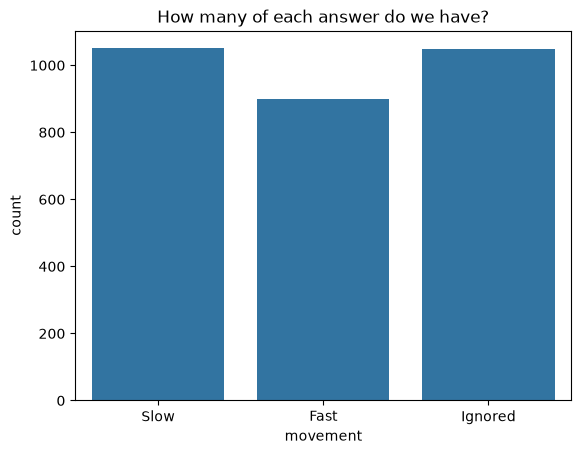

In [19]:
sns.countplot(x="movement", data=df)
plt.title("How many of each answer do we have?")
plt.show()

### How do we FIX biased data?

| Fix | How | Note |
|---|---|---|
| Collect more data | get more rows of the rare answer | always the best fix |
| Undersampling | delete rows of the common answer | throws away data |


**Our data is reasonably balanced**, so no fix is needed here.

Always run this check anyway — it takes 5 seconds and it saves you from a useless model.

### Which spot in the shop is best?

Again, we can answer the business question from the data alone, before any model.

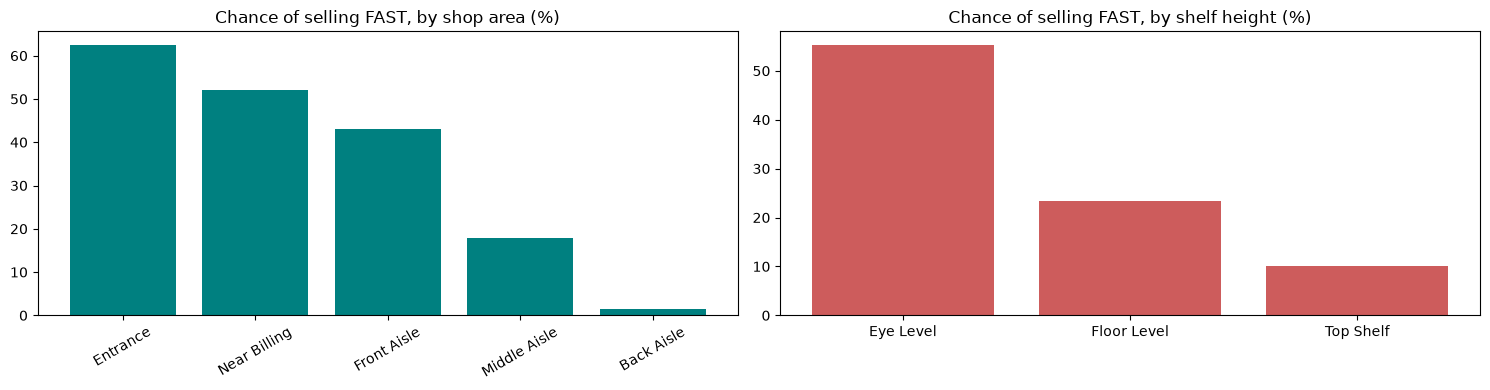

By area:
zone_name
Entrance        62.5
Near Billing    52.1
Front Aisle     43.1
Middle Aisle    17.9
Back Aisle       1.5
Corner Shelf     NaN
Name: count, dtype: float64

By height:
height_name
Eye Level      55.3
Floor Level    23.4
Top Shelf      10.1
Name: count, dtype: float64


In [20]:
zone_names = {1: "Entrance", 2: "Near Billing", 3: "Front Aisle",
              4: "Middle Aisle", 5: "Back Aisle", 6: "Corner Shelf"}
height_names = {1: "Eye Level", 2: "Floor Level", 3: "Top Shelf"}

# we work on a COPY here, so that df keeps only numbers for the model
chart_df = df.copy()
chart_df["zone_name"] = chart_df["zone_code"].map(zone_names)
chart_df["height_name"] = chart_df["height_code"].map(height_names)

fast_only = chart_df[chart_df["movement"] == "Fast"]

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

zone_percent = (fast_only["zone_name"].value_counts() / chart_df["zone_name"].value_counts() * 100).round(1)
zone_percent = zone_percent.reindex(list(zone_names.values()))
axes[0].bar(zone_percent.index, zone_percent.values, color="teal")
axes[0].set_title("Chance of selling FAST, by shop area (%)")
axes[0].tick_params(axis="x", rotation=30)

height_percent = (fast_only["height_name"].value_counts() / chart_df["height_name"].value_counts() * 100).round(1)
height_percent = height_percent.reindex(list(height_names.values()))
axes[1].bar(height_percent.index, height_percent.values, color="indianred")
axes[1].set_title("Chance of selling FAST, by shelf height (%)")

plt.tight_layout()
plt.show()

print("By area:")
print(zone_percent)
print()
print("By height:")
print(height_percent)

---
# STEP 5 — Scaling the Data

## 5.1 Separate X and y

- **X** = the input columns
- **y** = the answer column

In [21]:
X = df.drop("movement", axis=1)
y = df["movement"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (2997, 8)
y shape: (2997,)


,zone_code,height_code,item_category_code,price,discount_percent,daily_customer_traffic,nearby_promotion,city_code
0,3,2,8,6.642487,30.0,260.0,1,1
1,4,1,6,7.044033,15.0,251.0,1,1
2,5,1,7,6.526495,30.0,140.0,0,2
3,5,1,2,7.211557,25.0,100.0,0,1
4,2,2,3,6.331502,5.0,255.0,0,1


## 5.2 Why do we need scaling?

Look at the numbers below. Some columns have very big values and some have very small ones.

The model can think the bigger number is more important, which is wrong.
Scaling brings every column to the same range.

In [22]:
X.describe().round(2)

,zone_code,height_code,item_category_code,price,discount_percent,daily_customer_traffic,nearby_promotion,city_code
count,2997.00,2997.00,2997.00,2997.00,2997.00,2997.00,2997.00,2997.00
mean,3.47,1.99,4.49,7.11,14.95,246.99,0.39,1.40
std,1.69,0.83,2.27,0.67,9.95,102.41,0.49,0.49
min,1.00,1.00,1.00,4.72,0.00,20.00,0.00,1.00
25%,2.00,1.00,3.00,6.68,5.00,146.00,0.00,1.00
50%,3.00,2.00,5.00,7.15,15.00,280.00,0.00,1.00
75%,5.00,3.00,6.00,7.59,25.00,333.00,1.00,2.00
max,6.00,3.00,8.00,8.91,30.00,441.00,1.00,2.00


## 5.3 Create the scaler

`StandardScaler` changes every column so that its mean becomes 0.

In [23]:
scaler = StandardScaler()

print("Step 5 done - scaler is ready")

Step 5 done - scaler is ready


---
# STEP 6 — Fit and Transform

- **fit** = the scaler looks at the data and learns the mean and the spread
- **transform** = the scaler changes the numbers

`fit_transform` does both together in one line.

In [24]:
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,zone_code,height_code,item_category_code,price,discount_percent,daily_customer_traffic,nearby_promotion,city_code
0,-0.280205,0.011303,1.546014,-0.695469,1.511661,0.127049,1.256652,-0.808122
1,0.310354,-1.198477,0.664552,-0.092831,0.004526,0.039153,1.256652,-0.808122
2,0.900913,-1.198477,1.105283,-0.869549,1.511661,-1.044895,-0.795765,1.237437
3,0.900913,-1.198477,-1.098372,0.158588,1.009283,-1.435543,-0.795765,-0.808122
4,-0.870764,0.011303,-0.657641,-1.162193,-1.000231,0.078218,-0.795765,-0.808122


In [25]:
X_scaled.describe().round(2)

,zone_code,height_code,item_category_code,price,discount_percent,daily_customer_traffic,nearby_promotion,city_code
count,2997.00,2997.00,2997.00,2997.00,2997.00,2997.00,2997.00,2997.00
mean,-0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.46,-1.20,-1.54,-3.58,-1.50,-2.22,-0.80,-0.81
25%,-0.87,-1.20,-0.66,-0.64,-1.00,-0.99,-0.80,-0.81
50%,-0.28,0.01,0.22,0.07,0.00,0.32,-0.80,-0.81
75%,0.90,1.22,0.66,0.72,1.01,0.84,1.26,1.24
max,1.49,1.22,1.55,2.70,1.51,1.89,1.26,1.24


Look at the `mean` row above — every column is now close to **0**.

The shape of the data did not change, only the scale.

---
# STEP 7 — Divide into Train and Test

We keep **80% for training** and **hide 20% for testing**.

The model learns from the training part only. The testing part is the exam — the model has
never seen it. This is the only honest way to check a model.

`stratify=y` keeps the same mix of answers in both parts.
`random_state=42` makes everyone in the class get the same split.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

print("Training rows:", X_train.shape[0])
print("Testing rows :", X_test.shape[0])

Training rows: 2397
Testing rows : 600


---
# STEP 8 — Train the Model

This is the actual machine learning. It is **one line**: `model.fit()`

## Why Logistic Regression?

**Logistic Regression** works very well here, and the reason is worth explaining.

Look at how the zones are numbered:

| Code | Zone | Code | Height |
|---|---|---|---|
| 1 | Entrance (best) | 1 | Eye Level (best) |
| 2 | Near Billing Counter | 2 | Floor Level |
| 3 | Front Aisle | 3 | Top Shelf (worst) |
| 4 | Middle Aisle | | |
| 5 | Back Aisle | | |
| 6 | Corner Shelf (worst) | | |

The numbers are **in order from best spot to worst spot**. Because of that, the number
itself carries meaning: a smaller number really does mean a better position. This is called
**ordinal encoding**, and it is what lets a straight-line model understand the shop layout.

This project is also about **probability**. We do not just want the answer “Fast” — we want
to know it is 78% Fast and 20% Slow, so the shop manager can decide how much risk to take.
Logistic Regression gives well-behaved probabilities, which is exactly what we need.

In [27]:
model = LogisticRegression(max_iter=2000)

model.fit(X_train, y_train)

print("Step 8 done - model is trained")

Step 8 done - model is trained


---
# STEP 9 — Make Predictions

Now we give the model the **test data** (which it has never seen) and ask for its answers.

In [28]:
y_pred = model.predict(X_test)

print("First 10 predictions :", list(y_pred[:10]))
print("First 10 real answers:", list(y_test[:10]))

First 10 predictions : ['Ignored', 'Slow', 'Slow', 'Slow', 'Ignored', 'Slow', 'Fast', 'Ignored', 'Fast', 'Slow']
First 10 real answers: ['Ignored', 'Slow', 'Ignored', 'Slow', 'Ignored', 'Slow', 'Slow', 'Ignored', 'Fast', 'Ignored']


In [29]:
result = pd.DataFrame({"Real Answer": y_test.values,
                       "Model Prediction": y_pred})

result.head(15)

,Real Answer,Model Prediction
0,Ignored,Ignored
1,Slow,Slow
2,Ignored,Slow
3,Slow,Slow
4,Ignored,Ignored
5,Slow,Slow
6,Slow,Fast
7,Ignored,Ignored
8,Fast,Fast
9,Ignored,Slow


---
# STEP 10 — Check the Model

## 10.1 How many did the model get correct?

In [30]:
correct = (y_pred == y_test).sum()
total = len(y_test)

print("Total test rows      :", total)
print("Correctly predicted  :", correct)
print("Wrongly predicted    :", total - correct)

Total test rows      : 600
Correctly predicted  : 502
Wrongly predicted    : 98


In [31]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy in percent:", round(accuracy * 100, 2), "%")

Accuracy: 0.8366666666666667
Accuracy in percent: 83.67 %


In [32]:
baseline = df["movement"].value_counts(normalize=True).max()

print("If we always answered the most common answer:", round(baseline * 100, 2), "%")
print("Our model                                   :", round(accuracy * 100, 2), "%")
print()
print("Our model must be clearly better than the baseline, otherwise it learned nothing.")

If we always answered the most common answer: 35.04 %
Our model                                   : 83.67 %

Our model must be clearly better than the baseline, otherwise it learned nothing.


## 10.2 Confusion Matrix

This table shows exactly which mistakes the model made.
The numbers on the diagonal are the correct answers.

In [33]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

print(cm)

[[151   0  29]
 [  0 185  25]
 [ 22  22 166]]


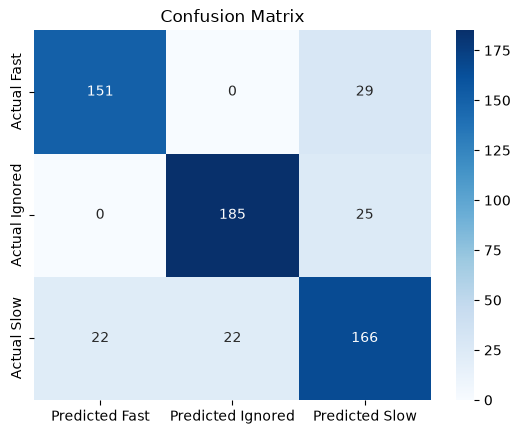

In [34]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted " + c for c in model.classes_],
            yticklabels=["Actual " + c for c in model.classes_])
plt.title("Confusion Matrix")
plt.show()

## 10.3 Full report

In [35]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        Fast       0.87      0.84      0.86       180
     Ignored       0.89      0.88      0.89       210
        Slow       0.75      0.79      0.77       210

    accuracy                           0.84       600
   macro avg       0.84      0.84      0.84       600
weighted avg       0.84      0.84      0.84       600



| Word | Meaning |
|---|---|
| precision | when the model gave this answer, how often was it right |
| recall | out of all the real cases, how many did the model catch |
| f1-score | balance of precision and recall |
| support | how many rows of that type were in the test data |

## 10.4 Check the training score also

If the training score is very high but the test score is low, the model has **memorised**
the training data instead of learning. That is called **overfitting**.

In [36]:
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print("Training accuracy:", round(train_accuracy * 100, 2), "%")
print("Testing accuracy :", round(test_accuracy * 100, 2), "%")
print("Difference       :", round((train_accuracy - test_accuracy) * 100, 2), "%")

Training accuracy: 84.61 %
Testing accuracy : 83.67 %
Difference       : 0.94 %


A small difference means the model is healthy.

A large difference (more than about 10%) means overfitting — use a simpler model, or a
smaller `max_depth`, or collect more data.

---
# STEP 11 — Test the Model with New Data

Now we give the model values that are **not in the file at all** — values that we type
ourselves.

**Very important:** new data must be prepared in exactly the same way as the training data.

1. Put the values in a DataFrame with the **same column names and same order**
2. Scale it with the **same scaler**
3. Only then call `predict`

Column order: `zone_code, height_code, item_category_code, price, discount_percent, daily_customer_traffic, nearby_promotion, city_code`

## 11.1 Type your own values

Change the numbers below to anything you like, then run the cell.

In [37]:
new_row = pd.DataFrame([[1, 1, 3, 400, 20, 380, 1, 1]], columns=X.columns)

new_row

,zone_code,height_code,item_category_code,price,discount_percent,daily_customer_traffic,nearby_promotion,city_code
0,1,1,3,400,20,380,1,1


**Do not forget the log transform.**

In Step 4.3 we changed `price` with a log. The model learned from log values, so any new
value must also be converted the same way, otherwise the answer will be completely wrong.

In [38]:
new_row["price"] = np.log(new_row["price"] + 1)

new_row

,zone_code,height_code,item_category_code,price,discount_percent,daily_customer_traffic,nearby_promotion,city_code
0,1,1,3,5.993961,20,380,1,1


## 11.2 Scale the new data

We use `transform` here, **not** `fit_transform`.

The scaler already learned in Step 6. If we used `fit_transform` here, it would learn again
from one single row and the prediction would be wrong.

In [39]:
new_row_scaled = scaler.transform(new_row)

new_row_scaled = pd.DataFrame(new_row_scaled, columns=X.columns)

new_row_scaled

,zone_code,height_code,item_category_code,price,discount_percent,daily_customer_traffic,nearby_promotion,city_code
0,-1.461324,-1.198477,-0.657641,-1.668772,0.506904,1.298992,1.256652,-0.808122


## 11.3 Predict

In [40]:
prediction = model.predict(new_row_scaled)

print("If we place this item here, will it sell fast?", prediction[0])

If we place this item here, will it sell fast? Fast


## 11.4 How sure is the model?

`predict` gives only the answer. `predict_proba` gives the **chance** behind that answer.

In [41]:
probability = model.predict_proba(new_row_scaled)

chances = pd.DataFrame({"answer": model.classes_,
                        "chance_%": (probability[0] * 100).round(2)})

chances

,answer,chance_%
0,Fast,100.0
1,Ignored,0.0
2,Slow,0.0


## 11.5 Try a few different cases at once

In [42]:
many_rows = pd.DataFrame([
    [1, 1, 3, 400, 20, 380, 1, 1],    # Sweets at eye level near the entrance, Kathmandu
    [6, 3, 2, 15000, 0, 90, 0, 2],    # expensive Electronics on a top corner shelf, Pokhara
    [4, 1, 6, 300, 10, 250, 0, 1],    # Groceries at eye level in the middle aisle
    [2, 2, 8, 800, 25, 400, 1, 1],    # Toys at floor level near the billing counter
], columns=X.columns)
many_rows["price"] = np.log(many_rows["price"] + 1)

many_rows_scaled = pd.DataFrame(scaler.transform(many_rows), columns=X.columns)

results = many_rows.copy()
results["prediction"] = model.predict(many_rows_scaled)

results

,zone_code,height_code,item_category_code,price,discount_percent,daily_customer_traffic,nearby_promotion,city_code,prediction
0,1,1,3,5.993961,20,380,1,1,Fast
1,6,3,2,9.615872,0,90,0,2,Ignored
2,4,1,6,5.707110,10,250,0,1,Slow
3,2,2,8,6.685861,25,400,1,1,Fast


---
# STEP 12 — Export the Model for the Web App

Training took a few seconds here, but on real data it can take hours. We do not want to
train the model again every time someone opens the app.

So we **save the trained model into a file**. This is called **pickling**.

Think of it like cooking: training is the cooking, the `.pkl` file is the meal in the
freezer, and the app just reheats it.

## 12.1 What do we save?

We must save **three** things together, not just the model:

| What | Why |
|---|---|
| the **model** | it makes the prediction |
| the **scaler** | new data must be scaled the same way, or the answer will be wrong |
| the **column names** | so the app sends the columns in the correct order |

In [43]:
import joblib

package = {
    "model": model,
    "scaler": scaler,
    "columns": list(X.columns)
}

joblib.dump(package, "shelf_model.pkl")

print("Model saved as shelf_model.pkl")

Model saved as shelf_model.pkl


## 12.2 Always test the saved file

Never build an app on top of a `.pkl` file you have not tested.

In [44]:
loaded = joblib.load("shelf_model.pkl")

loaded_model = loaded["model"]
loaded_scaler = loaded["scaler"]
loaded_columns = loaded["columns"]

print("Columns the model expects:", loaded_columns)

Columns the model expects: ['zone_code', 'height_code', 'item_category_code', 'price', 'discount_percent', 'daily_customer_traffic', 'nearby_promotion', 'city_code']


In [45]:
test_row = pd.DataFrame([[1, 1, 3, 400, 20, 380, 1, 1]], columns=loaded_columns)
test_row["price"] = np.log(test_row["price"] + 1)

test_row_scaled = pd.DataFrame(loaded_scaler.transform(test_row), columns=loaded_columns)

print("Prediction from the saved file:", loaded_model.predict(test_row_scaled)[0])

Prediction from the saved file: Fast


If the answer above is the same as in Step 11.3, the file is correct and ready to use.

## 12.3 Create requirements.txt automatically

When we put the app on the internet, the server is an empty computer. It has no pandas and
no scikit-learn until we tell it what to install. That list goes in **requirements.txt**.

There is one important detail. A `.pkl` file saved by scikit-learn version 1.5 may **refuse
to open** on a server that installed version 1.8. This is the most common reason a working
app fails after hosting.

The safe way is to write down the exact versions of **this** computer, because this is the
computer that created the `.pkl` file.

In [46]:
import sklearn

lines = [
    "streamlit",
    "pandas==" + pd.__version__,
    "numpy==" + np.__version__,
    "scikit-learn==" + sklearn.__version__,
    "joblib==" + joblib.__version__,
]

text = "\n".join(lines)

file = open("requirements.txt", "w")
file.write(text)
file.close()

print("requirements.txt created with these lines:")
print()
print(text)

requirements.txt created with these lines:

streamlit
pandas==3.0.5
numpy==2.4.6
scikit-learn==1.9.0
joblib==1.5.3


## 12.4 What to upload to GitHub

| File | Needed for the app? |
|---|---|
| `shelf_app.py` | YES - the app itself |
| `shelf_model.pkl` | YES - the trained model |
| `requirements.txt` | YES - the list of libraries |
| `shelf_placement.csv` | No - only used for training |
| this notebook | No - but nice to keep |

Upload the **first three** to a **public** GitHub repository, then deploy from
share.streamlit.io with Main file path = `shelf_app.py`.

The app does **not** read the CSV file. It only reads the `.pkl` file. That is the whole
point of exporting the model.

---
# Finished

| Step | What we did |
|---|---|
| 0 | Installed the libraries |
| 1 | Imported libraries |
| 2 | Imported the CSV file |
| 3 | Copied it into a DataFrame |
| 4 | Fixed nulls, removed outliers, checked skew and bias |
| 5 | Separated X and y, created the scaler |
| 6 | fit_transform on the data |
| 7 | Split into 80% train and 20% test |
| 8 | Trained the Logistic Regression model |
| 9 | Predicted on the test data |
| 10 | Checked how many predictions were correct |
| 11 | Tested with our own new values |
| 12 | Saved `shelf_model.pkl` and created requirements.txt |

**Next:** run the web app.

```
streamlit run shelf_app.py
```